# ROC-Based Predictive Analysis: 30-Day Price Movement Classification

This notebook implements a data science workflow to predict 30-day price movements using Rate of Change (ROC) indicator.

**Objective:** Create a binary classification target where:
- `1` = Positive ROC (price increase over 30 days)
- `0` = Non-positive ROC (price stagnation or decrease over 30 days)

## Initial imports and basic settings

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, auc)

##  Load pipeline output + scale

In [22]:
df = pd.read_csv('../model_data.csv')

df.head()

,Date,MACD_Signal,BB_Width,RSI_lag1,ATR_Pct,SMA20_Dist,Stoch_K,ROC_roll5_mean,Volume_Ratio,CCI,Price_Direction_30d
0,1999-04-05,0.000043,0.165902,53.267613,0.070849,-0.035639,59.007924,-0.794889,1.096819,-2430.159359,1
1,1999-04-06,-0.000018,0.171081,50.304723,0.071632,-0.055301,43.711443,-3.070597,0.777656,-2246.215563,1
2,1999-04-07,-0.000038,0.157911,48.005570,0.067320,0.026581,48.084269,-2.457141,1.027057,-2462.768192,1
3,1999-04-08,-0.000019,0.153657,55.179098,0.065174,0.045705,61.198544,-1.357794,1.593394,-2537.529485,0
4,1999-04-09,0.000012,0.154960,56.664675,0.063724,0.026737,75.403923,0.664012,0.597464,-2526.145480,0


In [24]:
FEATURES = ['MACD_Signal', 'BB_Width', 'RSI_lag1', 'ATR_Pct', 'SMA20_Dist', 'Stoch_K', 'ROC_roll5_mean', 'Volume_Ratio', 'CCI']
TARGET   = 'Price_Direction_30d'

X = df[FEATURES]
y = df[TARGET]

# Chronological split — no shuffle to avoid future leakage
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15/0.85, shuffle=False)

# Scale — fit only on train
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")

Train: 4535  Val: 972  Test: 972

Train class balance:
Price_Direction_30d
1    0.552
0    0.448
Name: proportion, dtype: float64

Test class balance:
Price_Direction_30d
1    0.585
0    0.415
Name: proportion, dtype: float64


## Feature distributions by class

IndexError: index 8 is out of bounds for axis 0 with size 8

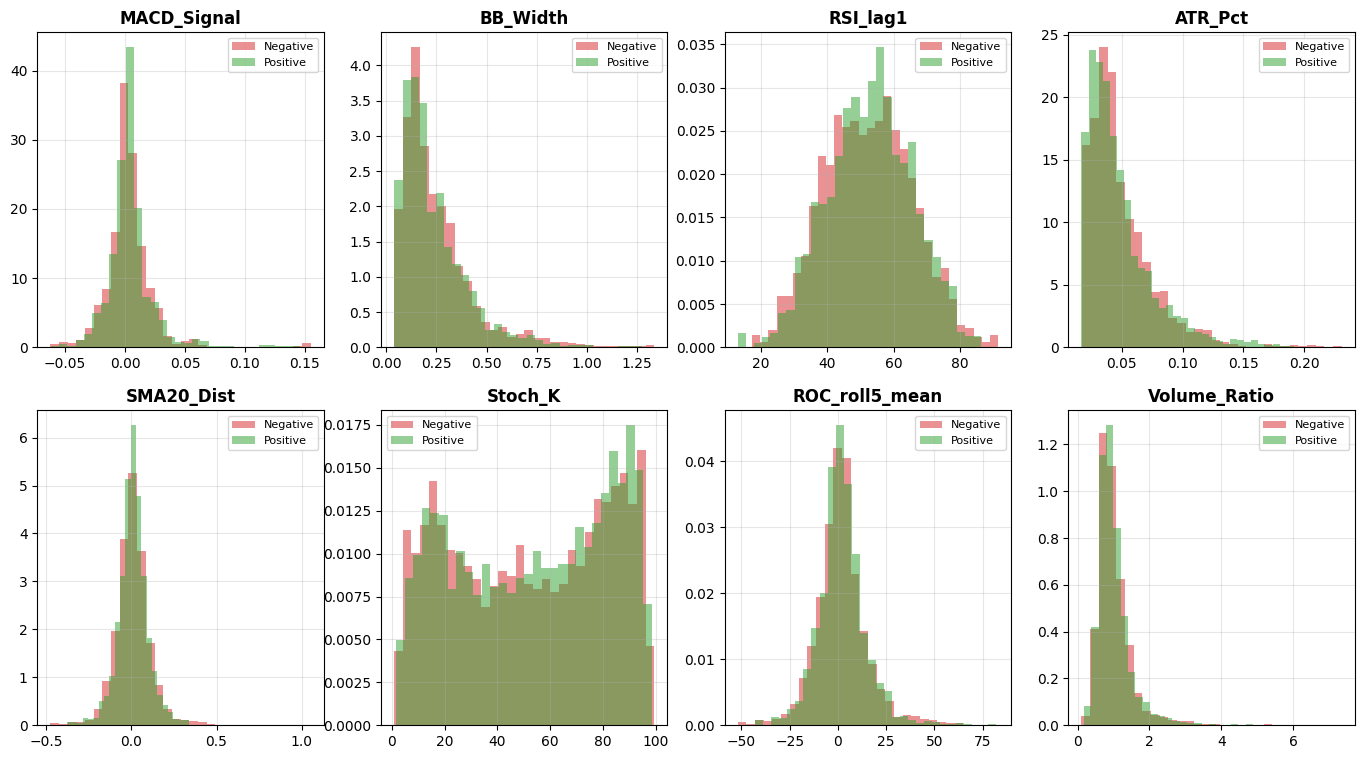

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    for label, color, name in [(0, '#d62728', 'Negative'), (1, '#2ca02c', 'Positive')]:
        vals = X_train[feat][y_train == label]
        axes[i].hist(vals, bins=30, alpha=0.5, color=color, label=name, density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

axes[-1].set_visible(False)
fig.suptitle('Feature Distributions by Target Class (Train Set)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## Train with RandomizedSearchCV

In [15]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [4, 8, 10, None],
    'min_samples_split': [5, 10, 15, 25],
    'min_samples_leaf':  [12, 17, 23, 30],
    'max_features':      ['sqrt', 'log2', None],
    'bootstrap':         [True, False]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_sc, y_train)
best_rf = rf_search.best_estimator_

print("\nBest parameters:")
for k, v in rf_search.best_params_.items():
    print(f"  {k:<22} {v}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best parameters:
  n_estimators           500
  min_samples_split      25
  min_samples_leaf       12
  max_features           None
  max_depth              None
  bootstrap              False


##  Performance across all splits

In [16]:
y_train_pred = best_rf.predict(X_train_sc)
y_val_pred = best_rf.predict(X_val_sc)
y_test_pred = best_rf.predict(X_test_sc)
y_val_proba = best_rf.predict_proba(X_val_sc)[:, 1]
y_test_proba = best_rf.predict_proba(X_test_sc)[:, 1]

metrics = {
    'Accuracy' : accuracy_score,
    'Precision': precision_score,
    'Recall'   : recall_score,
    'F1-Score' : f1_score,
}

print(f"\n{'Metric':<12} {'Train':>10} {'Val':>10} {'Test':>10}")
print("-" * 45)
for name, fn in metrics.items():
    tr = fn(y_train, y_train_pred)
    va = fn(y_val,   y_val_pred)
    te = fn(y_test,  y_test_pred)
    print(f"{name:<12} {tr:>10.4f} {va:>10.4f} {te:>10.4f}")

print(f"{'ROC-AUC':<12} {'—':>10} {roc_auc_score(y_val, y_val_proba):>10.4f} {roc_auc_score(y_test, y_test_proba):>10.4f}")

gap = accuracy_score(y_train, y_train_pred) - accuracy_score(y_test, y_test_pred)
print(f"\nOverfitting gap (train − test accuracy): {gap:.4f}")


Metric            Train        Val       Test
---------------------------------------------
Accuracy         0.8077     0.3868     0.4239
Precision        0.8448     0.6742     0.5333
Recall           0.7982     0.1386     0.1265
F1-Score         0.8209     0.2300     0.2045
ROC-AUC               —     0.4997     0.4729

Overfitting gap (train − test accuracy): 0.3838


## Confusion matrix + ROC curve

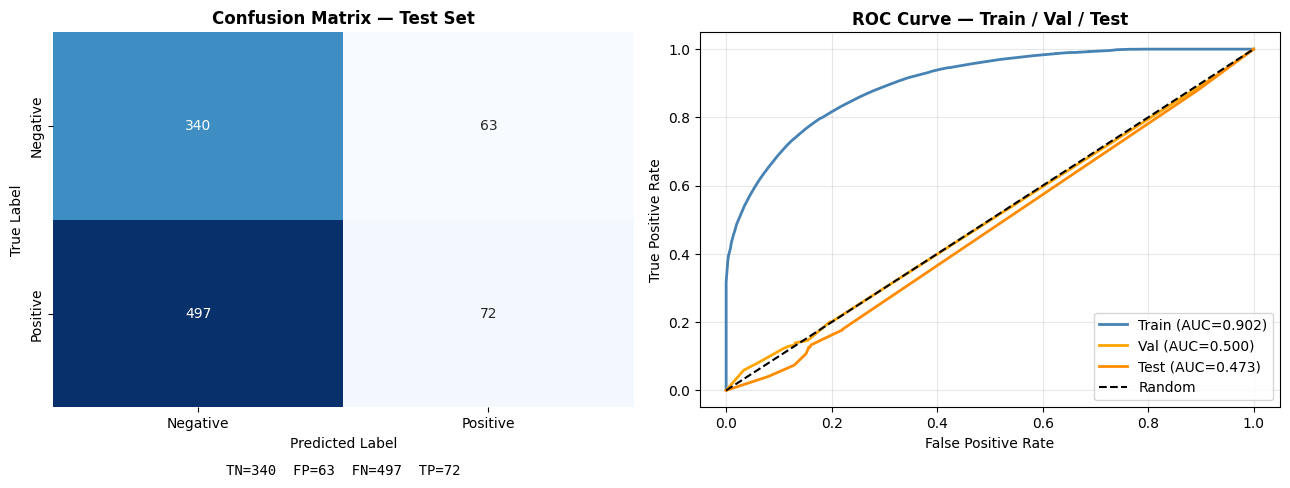

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_title('Confusion Matrix — Test Set', fontweight='bold')
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.18, f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
             transform=axes[0].transAxes, ha='center', fontsize=10, family='monospace')

# ROC — train / val / test on same plot to visualise overfitting
for X_sc, y_true, y_prob, label, color in [
    (X_train_sc, y_train, best_rf.predict_proba(X_train_sc)[:, 1], 'Train',  'steelblue'),
    (X_val_sc,   y_val,   y_val_proba,                              'Val',    'orange'),
    (X_test_sc,  y_test,  y_test_proba,                             'Test',   'darkorange'),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1].plot(fpr, tpr, lw=2,
                 label=f'{label} (AUC={roc_auc_score(y_true, y_prob):.3f})',
                 color=color)

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Train / Val / Test', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Feature importance

    Feature  Importance
        ATR    0.307324
        CCI    0.255578
MACD_Signal    0.218377
        RSI    0.079397
        ROC    0.075677
    Stoch_K    0.063648


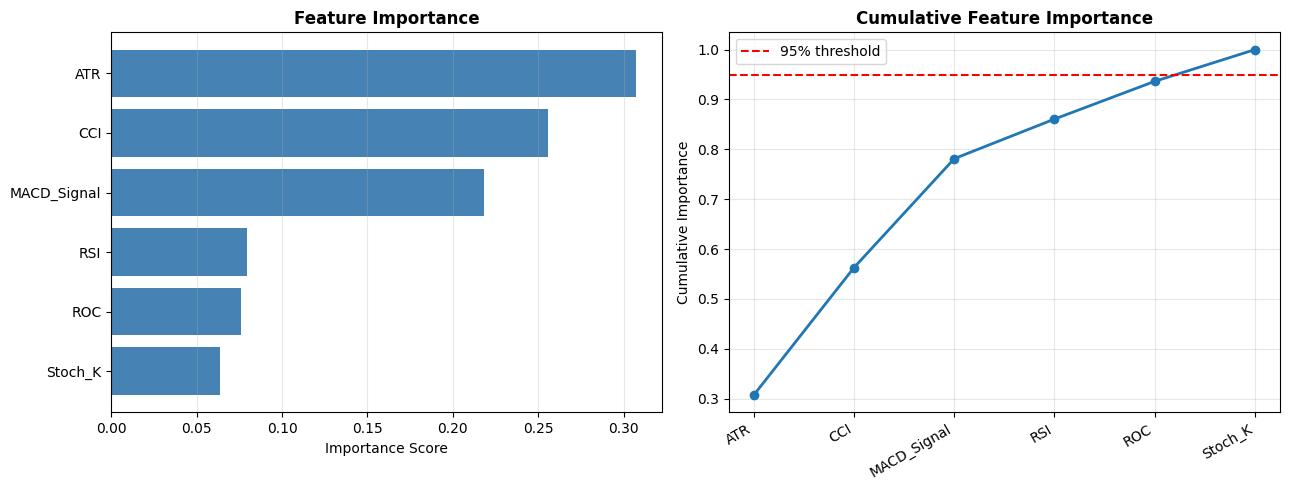


Features needed for 95% cumulative importance: 6


In [18]:
feat_imp = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(feat_imp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Feature Importance', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

cumsum = feat_imp['Importance'].cumsum()
axes[1].plot(range(1, len(cumsum) + 1), cumsum, marker='o', linewidth=2)
axes[1].axhline(0.95, color='red', linestyle='--', label='95% threshold')
axes[1].set_xticks(range(1, len(FEATURES) + 1))
axes[1].set_xticklabels(feat_imp['Feature'], rotation=30, ha='right')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title('Cumulative Feature Importance', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

n_for_95 = int((cumsum >= 0.95).idxmax()) + 1
print(f"\nFeatures needed for 95% cumulative importance: {n_for_95}")

## Prediction confidence

High confidence (prob ≥ 0.7 or ≤ 0.3) : 970  (99.8%)
Low  confidence (0.3 < prob < 0.7)     : 2  (0.2%)

Accuracy — high confidence: 0.4227
Accuracy — low  confidence: 1.0000


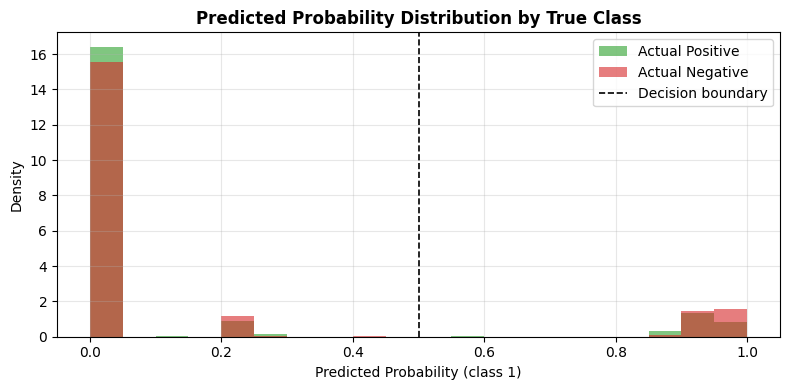

In [19]:
results_df = pd.DataFrame({
    'Actual':      y_test.values,
    'Predicted':   y_test_pred,
    'Probability': y_test_proba,
    'Correct':     y_test.values == y_test_pred
})

high_conf = (results_df['Probability'] >= 0.7) | (results_df['Probability'] <= 0.3)
low_conf  = ~high_conf

print(f"High confidence (prob ≥ 0.7 or ≤ 0.3) : {high_conf.sum()}  ({high_conf.mean()*100:.1f}%)")
print(f"Low  confidence (0.3 < prob < 0.7)     : {low_conf.sum()}  ({low_conf.mean()*100:.1f}%)")
print(f"\nAccuracy — high confidence: {results_df[high_conf]['Correct'].mean():.4f}")
print(f"Accuracy — low  confidence: {results_df[low_conf]['Correct'].mean():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in [(1, '#2ca02c', 'Actual Positive'), (0, '#d62728', 'Actual Negative')]:
    ax.hist(results_df[results_df['Actual'] == label]['Probability'],
            bins=20, alpha=0.6, color=color, label=name, density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Decision boundary')
ax.set_xlabel('Predicted Probability (class 1)')
ax.set_ylabel('Density')
ax.set_title('Predicted Probability Distribution by True Class', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
print("=" * 55)
print("RANDOM FOREST — FINAL SUMMARY")
print("=" * 55)
print(f"  Features          : {FEATURES}")
print(f"  Train / Val / Test: {len(X_train)} / {len(X_val)} / {len(X_test)}")
print(f"  Test Accuracy     : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  Test F1           : {f1_score(y_test, y_test_pred):.4f}")
print(f"  Test ROC-AUC      : {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"  Top feature       : {feat_imp.iloc[0]['Feature']} ({feat_imp.iloc[0]['Importance']:.4f})")
print(f"  Overfitting gap   : {gap:.4f}")
print("=" * 55)

RANDOM FOREST — FINAL SUMMARY
  Features          : ['RSI', 'MACD_Signal', 'ATR', 'Stoch_K', 'CCI', 'ROC']
  Train / Val / Test: 4535 / 972 / 972
  Test Accuracy     : 0.4239
  Test F1           : 0.2045
  Test ROC-AUC      : 0.4729
  Top feature       : ATR (0.3073)
  Overfitting gap   : 0.3838
